# Introduction

Do higher film budgets lead to more box office revenue? Let's find out if there's a relationship using the movie budgets and financial performance data that I've scraped from [the-numbers.com](https://www.the-numbers.com/movie/budgets) on **May 1st, 2018**. 

<img src=https://i.imgur.com/kq7hrEh.png>

# Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Read the Data

In [3]:
data = pd.read_csv('../../data/cost_revenue_dirty.csv')

# Explore and Clean the Data

### Dataset Structure and Quality

Inspect the shape, null values, duplicates, and column types before any transformations.

In [4]:
data.shape

(5391, 6)

In [5]:
data.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,8/2/1915,The Birth of a Nation,"$110,000","$11,000,000","$10,000,000"
1,5140,5/9/1916,Intolerance,"$385,907",$0,$0
2,5230,12/24/1916,"20,000 Leagues Under the Sea","$200,000","$8,000,000","$8,000,000"
3,5299,9/17/1920,Over the Hill to the Poorhouse,"$100,000","$3,000,000","$3,000,000"
4,5222,1/1/1925,The Big Parade,"$245,000","$22,000,000","$11,000,000"


In [6]:
data.tail()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5386,2950,10/8/2018,Meg,"$15,000,000",$0,$0
5387,126,12/18/2018,Aquaman,"$160,000,000",$0,$0
5388,96,12/31/2020,Singularity,"$175,000,000",$0,$0
5389,1119,12/31/2020,Hannibal the Conqueror,"$50,000,000",$0,$0
5390,2517,12/31/2020,"Story of Bonnie and Clyde, The","$20,000,000",$0,$0


In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Rank                   5391 non-null   int64 
 1   Release_Date           5391 non-null   object
 2   Movie_Title            5391 non-null   object
 3   USD_Production_Budget  5391 non-null   object
 4   USD_Worldwide_Gross    5391 non-null   object
 5   USD_Domestic_Gross     5391 non-null   object
dtypes: int64(1), object(5)
memory usage: 252.8+ KB


In [8]:
data.sample(5)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
1801,4725,4/19/2002,Nueve Reinas,"$1,500,000","$12,412,889","$1,222,889"
4829,2679,2/20/2015,"McFarland, USA","$17,000,000","$45,707,924","$44,480,275"
3731,1335,9/7/2010,Predators,"$40,000,000","$127,234,389","$52,000,688"
2881,2860,3/23/2007,The Hills Have Eyes II,"$15,000,000","$37,466,538","$20,804,166"
59,5227,6/13/1953,"The Beast from 20,000 Fathoms","$210,000","$5,000,000","$5,000,000"


### Data Type Conversions

### Converting Currency Columns to Numeric

Strip `$` signs and commas from the three monetary columns and convert to float so they can be used in calculations and plots.

In [9]:
chars_to_remove = ['$', ',', '%', ' ']

cols_to_clean = [
'USD_Production_Budget',
'USD_Worldwide_Gross',
'USD_Domestic_Gross',
 ]

for col in cols_to_clean:
    for char in chars_to_remove:
        data[col] = data[col].astype(str).str.replace(char, '', regex=False)
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [10]:
data.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,8/2/1915,The Birth of a Nation,110000,11000000,10000000
1,5140,5/9/1916,Intolerance,385907,0,0
2,5230,12/24/1916,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,9/17/1920,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1/1/1925,The Big Parade,245000,22000000,11000000


### Parsing Release Dates

Convert the `Release_Date` column from object strings to Pandas datetime so year and decade can be extracted later.

In [11]:
data['Release_Date'] = pd.to_datetime(data['Release_Date'], errors='coerce')

In [12]:
data.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,1915-08-02,The Birth of a Nation,110000,11000000,10000000
1,5140,1916-05-09,Intolerance,385907,0,0
2,5230,1916-12-24,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,1920-09-17,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1925-01-01,The Big Parade,245000,22000000,11000000


### Descriptive Statistics

### Descriptive Statistics

Summary statistics reveal budget and revenue distribution across the dataset: ranges, medians, and the spread between the bottom and top quartiles.

In [13]:
data.describe()

,Rank,Release_Date,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
count,"5,391.00",5391,"5,391.00","5,391.00","5,391.00"
mean,"2,696.00",2003-09-19 15:02:02.203672704,"31,113,737.58","88,855,421.96","41,235,519.44"
min,1.00,1915-08-02 00:00:00,"1,100.00",0.00,0.00
25%,"1,348.50",1999-12-02 12:00:00,"5,000,000.00","3,865,206.00","1,330,901.50"
50%,"2,696.00",2006-06-23 00:00:00,"17,000,000.00","27,450,453.00","17,192,205.00"
75%,"4,043.50",2011-11-23 00:00:00,"40,000,000.00","96,454,455.00","52,343,687.00"
max,"5,391.00",2020-12-31 00:00:00,"425,000,000.00","2,783,918,982.00","936,662,225.00"
std,"1,556.39",NaN,"40,523,796.88","168,457,757.00","66,029,346.27"


In [14]:
data[data.USD_Production_Budget == data.USD_Production_Budget.min()]

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
2427,5391,2005-05-08,My Date With Drew,1100,181041,181041


In [15]:
data[data.USD_Production_Budget == data.USD_Production_Budget.max()]

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
3529,1,2009-12-18,Avatar,425000000,2783918982,760507625


# Investigating the Zero Revenue Films

### Films with Zero Domestic Gross

Identify films reporting $0 in domestic (US) revenue — either unreleased, streaming-only, or internationally distributed titles.

In [16]:
zero_domestic = data[data['USD_Domestic_Gross'] == 0]
print(f'Number of movies with zero domestic gross: {len(zero_domestic)}')

Number of movies with zero domestic gross: 512


In [17]:
zero_domestic.sort_values(by='USD_Production_Budget', ascending=False).head(10)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5090,556,2015-12-31,"Don Gato, el inicio de la pandilla",80000000,4547660,0
4294,566,2012-12-31,Astérix et Obélix: Au service de Sa Majesté,77600000,60680125,0
5058,880,2015-11-12,The Ridiculous 6,60000000,0,0
5338,879,2017-04-08,The Dark Tower,60000000,0,0
5389,1119,2020-12-31,Hannibal the Conqueror,50000000,0,0
4295,1230,2012-12-31,Foodfight!,45000000,73706,0


### Films with Zero Worldwide Gross

Narrow the view further to films reporting no revenue globally, and rank them by production budget to spot the most expensive zero-earners.

In [18]:
zero_worldwide = data[data['USD_Worldwide_Gross'] == 0]
print(f'Number of movies with zero worldwide gross: {len(zero_worldwide)}')

Number of movies with zero worldwide gross: 357


In [19]:
zero_worldwide.sort_values(by='USD_Production_Budget', ascending=False).head(10)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5058,880,2015-11-12,The Ridiculous 6,60000000,0,0
5338,879,2017-04-08,The Dark Tower,60000000,0,0
5389,1119,2020-12-31,Hannibal the Conqueror,50000000,0,0
5092,1435,2015-12-31,The Crow,40000000,0,0
3300,1631,2008-12-31,Black Water Transit,35000000,0,0
5045,1656,2015-10-30,Freaks of Nature,33000000,0,0


### Filtering on Multiple Conditions

#### Practice

In [20]:
international_releases = data.loc[
    (data['USD_Domestic_Gross'] == 0) &
    (data['USD_Worldwide_Gross'] > 0)
]


In [21]:
print(f'Number of international releases: {len(international_releases)}')

Number of international releases: 155


In [22]:
international_releases.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
71,4310,1956-02-16,Carousel,3380000,3220,0
1579,5087,2001-02-11,Everything Put Together,500000,7890,0
1744,3695,2001-12-31,The Hole,7500000,10834406,0
2155,4236,2003-12-31,Nothing,4000000,63180,0
2203,2513,2004-03-31,The Touch,20000000,5918742,0


#### Filtering with `.query()`

Reproduce the international-releases filter using the `.query()` API as an alternative syntax.

In [23]:
international_releases_q = data.query(
    'USD_Domestic_Gross == 0 & USD_Worldwide_Gross > 0'
)

print(f'Number of international releases (using query): {len(international_releases_q)}')

Number of international releases (using query): 155


### Removing Unreleased Films

Films with a release date on or after the data-collection date (May 1, 2018) had no opportunity to earn revenue. Drop them to create `data_clean`.

In [24]:
# Date of Data Collection
scrape_date = pd.Timestamp('2018-5-1')

In [25]:
future_releases = data[data['Release_Date'] >= scrape_date]
future_releases

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5386,2950,2018-10-08,Meg,15000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5388,96,2020-12-31,Singularity,175000000,0,0
5389,1119,2020-12-31,Hannibal the Conqueror,50000000,0,0
5390,2517,2020-12-31,"Story of Bonnie and Clyde, The",20000000,0,0


In [26]:
data_clean = data.drop(future_releases.index)
data_clean.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,1915-08-02,The Birth of a Nation,110000,11000000,10000000
1,5140,1916-05-09,Intolerance,385907,0,0
2,5230,1916-12-24,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,1920-09-17,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1925-01-01,The Big Parade,245000,22000000,11000000


### Films that Failed to Recoup Their Budget

Calculate what proportion of films never recovered their production costs from worldwide revenue.

In [27]:
money_losing = data_clean.loc[data_clean['USD_Production_Budget'] > data_clean['USD_Worldwide_Gross']]

percentage = len(money_losing) / len(data_clean) * 100
print(f"{percentage:.2f}% of movies lost money.")


37.28% of movies lost money.


# Seaborn for Data Viz: Bubble Charts

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

### Budget vs Revenue Over Time

Plot every film as a point: release year on the x-axis, production budget on the y-axis, with point size and colour encoding worldwide gross.

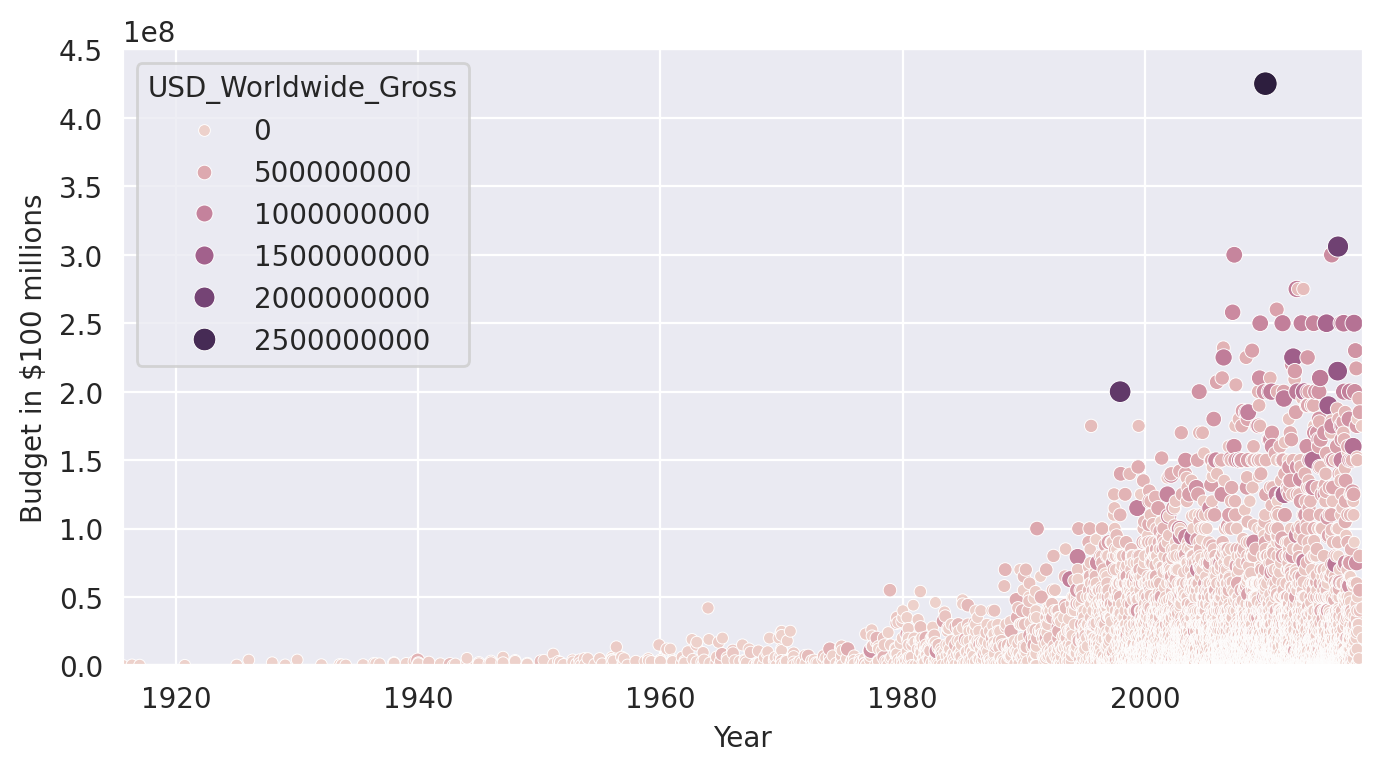

In [29]:
plt.figure(figsize=(8, 4), dpi=200)

with sns.axes_style("darkgrid"):
    ax = sns.scatterplot(
        data=data_clean,
        x='Release_Date',
        y='USD_Production_Budget',
        hue='USD_Worldwide_Gross',
        size='USD_Worldwide_Gross'
    )

    ax.set(
        ylim=(0, 450000000),
        xlim=(data_clean.Release_Date.min(),
              data_clean.Release_Date.max()),
        xlabel='Year',
        ylabel='Budget in $100 millions'
    )

plt.savefig("../../plots/budget_vs_revenue_bubble.png", dpi=150, bbox_inches="tight")
plt.show()

<img src=https://i.imgur.com/8fUn9T6.png>


# Grouping Releases by Decade

Derive a `Decade` column using floor division so films can be grouped and compared across eras.

In [30]:
data_clean['Decade'] = data_clean['Release_Date'].dt.year // 10 * 10
data_clean.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Decade
0,5293,1915-08-02,The Birth of a Nation,110000,11000000,10000000,1910
1,5140,1916-05-09,Intolerance,385907,0,0,1910
2,5230,1916-12-24,"20,000 Leagues Under the Sea",200000,8000000,8000000,1910
3,5299,1920-09-17,Over the Hill to the Poorhouse,100000,3000000,3000000,1920
4,5222,1925-01-01,The Big Parade,245000,22000000,11000000,1920


### Splitting the Dataset by Era

Separate pre-1970 films from modern films to compare how the budget-to-revenue relationship differs across eras.

In [31]:
old_films = data_clean[data_clean['Decade'] <= 1960]
new_films = data_clean[data_clean['Decade'] > 1960]

In [32]:
print(f"Number of old films: {len(old_films)}")
print(f"Number of new films: {len(new_films)}")

Number of old films: 153
Number of new films: 5231


In [33]:
new_films.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Decade
153,2159,1970-01-01,Waterloo,25000000,0,0,1970
154,2270,1970-01-01,Darling Lili,22000000,5000000,5000000,1970
155,3136,1970-01-01,Patton,12000000,62500000,62500000,1970
156,3277,1970-01-01,The Molly Maguires,11000000,2200000,2200000,1970
157,4265,1970-01-01,M*A*S*H,3500000,81600000,81600000,1970


# Seaborn Regression Plots

### Regression Line: Films from 1970 Onwards

Fit and visualise the linear relationship between budget and worldwide revenue for the modern film era.

In [34]:
# Regression parameters (from sklearn fit above)
theta_0 = regression.intercept_[0]                                                                                                                                                                                                     
theta_1 = regression.coef_[0][0]
r2 = regression.score(X, y)                                                                                                                                                                                                            
                                                                
formula_text = (                                                                                                                                                                                                                       
    f"Ŷ = {theta_0:,.0f} + {theta_1:.4f}·X\n"                   
    f"R² = {r2:.2%}"
)                                                                                                                                                                                                                                      

plt.figure(figsize=(8, 4), dpi=200)                                                                                                                                                                                                    
                                                                
with sns.axes_style('darkgrid'):
    ax = sns.regplot(
        data=new_films,
        x='USD_Production_Budget',
        y='USD_Worldwide_Gross',                                                                                                                                                                                                       
        color='#2f4b7c',
        scatter_kws={'alpha': 0.3},                                                                                                                                                                                                    
        line_kws={'color': '#ff7c43'}                           
    )
                                                                                                                                                                                                                                        
    ax.set(
        ylim=(0, 3_000_000_000),                                                                                                                                                                                                       
        xlim=(0, 450_000_000),                                  
        ylabel='Revenue in $ billions',
        xlabel='Budget in $ millions',
        title='Production Budget vs. Worldwide Revenue (Films 1970+)'
    )                                                                                                                                                                                                                                  

    # Format x-axis ticks as millions and y-axis ticks as billions                                                                                                                                                                     
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y/1e9:.1f}B'))                                                                                                                                                     

    # Annotate with the regression formula                                                                                                                                                                                             
    ax.text(                                                    
        0.02, 0.93,
        formula_text,                                                                                                                                                                                                                  
        transform=ax.transAxes,
        fontsize=9,                                                                                                                                                                                                                    
        verticalalignment='top',                                
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='#ff7c43')
    )                                                                                                                                                                                                                                  

plt.tight_layout()                                                                                                                                                                                                                     
plt.savefig("../../plots/regression_new_films.png", dpi=150, bbox_inches="tight")
plt.show()        

NameError: name 'regression' is not defined

# Run Your Own Regression with scikit-learn

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.linear_model import LinearRegression



In [ ]:
regression = LinearRegression()

In [ ]:

# Explanatory variable
X = pd.DataFrame(new_films, columns=['USD_Production_Budget'])

# Response variable to Target
y = pd.DataFrame(new_films,columns=['USD_Worldwide_Gross'])



In [ ]:
regression.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Theta 0
regression.intercept_

array([-8650768.00661096])

In [ ]:
# Theta one
regression.coef_

array([[3.12259592]])

In [ ]:
# R squared: Goodness to fit

r_score = regression.score(X,y)
print(f'The model explains {r_score:.2%} of the variance')

The model explains 55.77% of the variance


### Regression for Pre-1970 Films

Repeat the regression on old films to compare slope, intercept, and explanatory power against the modern era model.

In [ ]:
regression_old = LinearRegression()

In [ ]:
old_X = pd.DataFrame(old_films, columns = ["USD_Production_Budget"])
old_y = pd.DataFrame(old_films, columns = ["USD_Worldwide_Gross"])

In [ ]:
regression_old.fit(old_X,old_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
print(f'The slope coefficient is {regression_old.coef_[0][0]}')
print(f'THe intercept is {regression_old.intercept_[0]}')

The slope coefficient is 1.6477131440107315
THe intercept is 22821538.635080386


# Estimating Revenue from Budget

With slope and intercept in hand, the model equation can generate a point prediction for any given budget.

$$ REV\hat{ENUE} = \theta_0 + \theta_1 \cdot BUDGET $$

In [ ]:
theta_zero = regression_old.intercept_[0]     # intercept
theta_one = regression_old.coef_[0][0]        # slope

budget = 350_000_000  # $350 million

revenue_challenge = theta_zero + theta_one * budget

print(f"The estimated revenue of a $350 million budget is ${revenue_challenge:,.0f}")

The estimated revenue of a $350 million budget is $599,521,139


# Key Findings

- **Production budget explains 55.77% of the variance in worldwide revenue** for films released from 1970 onwards (R² = 0.5577).
- **Every $1 of production budget is associated with ~$3.12 in worldwide gross** (slope = 3.1226) for the modern era.
- **37.28% of all released films failed to recoup their production costs** from worldwide box-office revenue.
- **357 films reported zero worldwide gross**, including several with budgets above $60M — many were unreleased or streaming-only at the time of data collection.
- **155 international releases** earned worldwide revenue while recording zero domestic (US) gross.
- The highest-budget film in the dataset is Avatar ($425M budget), which grossed $2.78B worldwide — more than 6× its production cost.
- The lowest-budget film is My Date With Drew ($1,100 budget, 2005), which grossed $181,041 — a return of over 160×.
- Pre-1970 films show a weaker and shallower budget-to-revenue relationship (slope ≈ 1.65) compared to the modern era, reflecting structural differences in distribution and market scale.